# 🏦 Loan Default Prediction System

## 📌 Problem Statement
This project aims to build a machine learning system that predicts whether a loan applicant is likely to default based on their financial, personal, and credit-related attributes.

It is a **binary classification problem**:

- 1 → Non-default (good borrower)
- 0 → Default (risky borrower)

Dataset: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data?resource=download

---

## 🎯 Objective
The goal of this project is to develop a **credit risk prediction system** that can:

- Identify high-risk loan applicants
- Support data-driven lending decisions
- Minimize financial risk for lenders
- Improve decision-making using machine learning

---

## 📊 Dataset Overview
The dataset contains applicant information across three major domains:

### 👤 Personal Attributes
- Age
- Gender
- Education
- Employment experience

### 💰 Financial Attributes
- Annual income
- Credit score
- Home ownership status

### 🏦 Loan Attributes
- Loan amount
- Loan purpose
- Interest rate
- Loan-to-income ratio

---

## 🧠 Methodology
The project follows a structured machine learning pipeline:

1. Data cleaning and preprocessing  
2. Exploratory Data Analysis (EDA)  
3. Feature engineering  
4. Encoding categorical variables  
5. Handling class imbalance  
6. Model training (XGBoost / ensemble models)  
7. Performance evaluation  
8. Threshold tuning for business decisions  

---

## 📌 Evaluation Strategy
Model performance is evaluated using:

- ROC-AUC (primary metric)
- Precision / Recall (especially for default class)
- F1-score
- Confusion Matrix

Accuracy is not the primary metric due to class imbalance.

---

## 🧠 Key Assumptions
- Tree-based models are used, so feature scaling is not required
- Class imbalance significantly impacts performance
- Business impact is prioritized over raw accuracy

## 1. Import Required Libraries

We start by importing all necessary libraries for data analysis, visualization, and machine learning.

In [1]:
import numpy as np
import pandas as pd
import warnings

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import shap
from sklearn.pipeline import Pipeline


warnings.filterwarnings("ignore")

C:\Users\osama\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Dataset

We load the dataset and inspect its structure to understand features and target variable.

In [2]:
df = pd.read_csv("../data/raw/loan_data.csv")

df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


## 3. Missing Values Check

We check for missing values to ensure data quality before analysis.

In [4]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

## 📊 4. Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to understand:
- Feature distributions
- Class imbalance in target variable
- Presence of outliers
- Relationships between key financial variables and loan default behavior

loan_status
0    35000
1    10000
Name: count, dtype: int64

Target Distribution (Proportion):
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


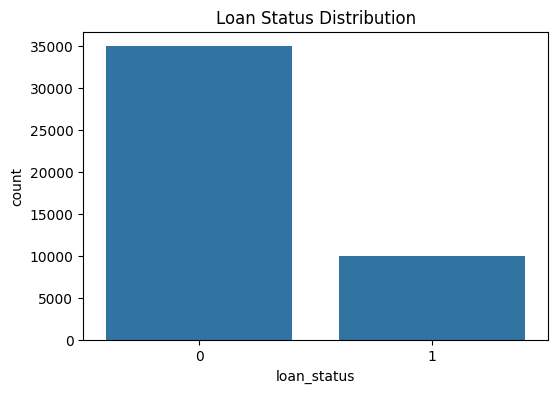

In [5]:
print(df["loan_status"].value_counts())

print("\nTarget Distribution (Proportion):")
print(df["loan_status"].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()


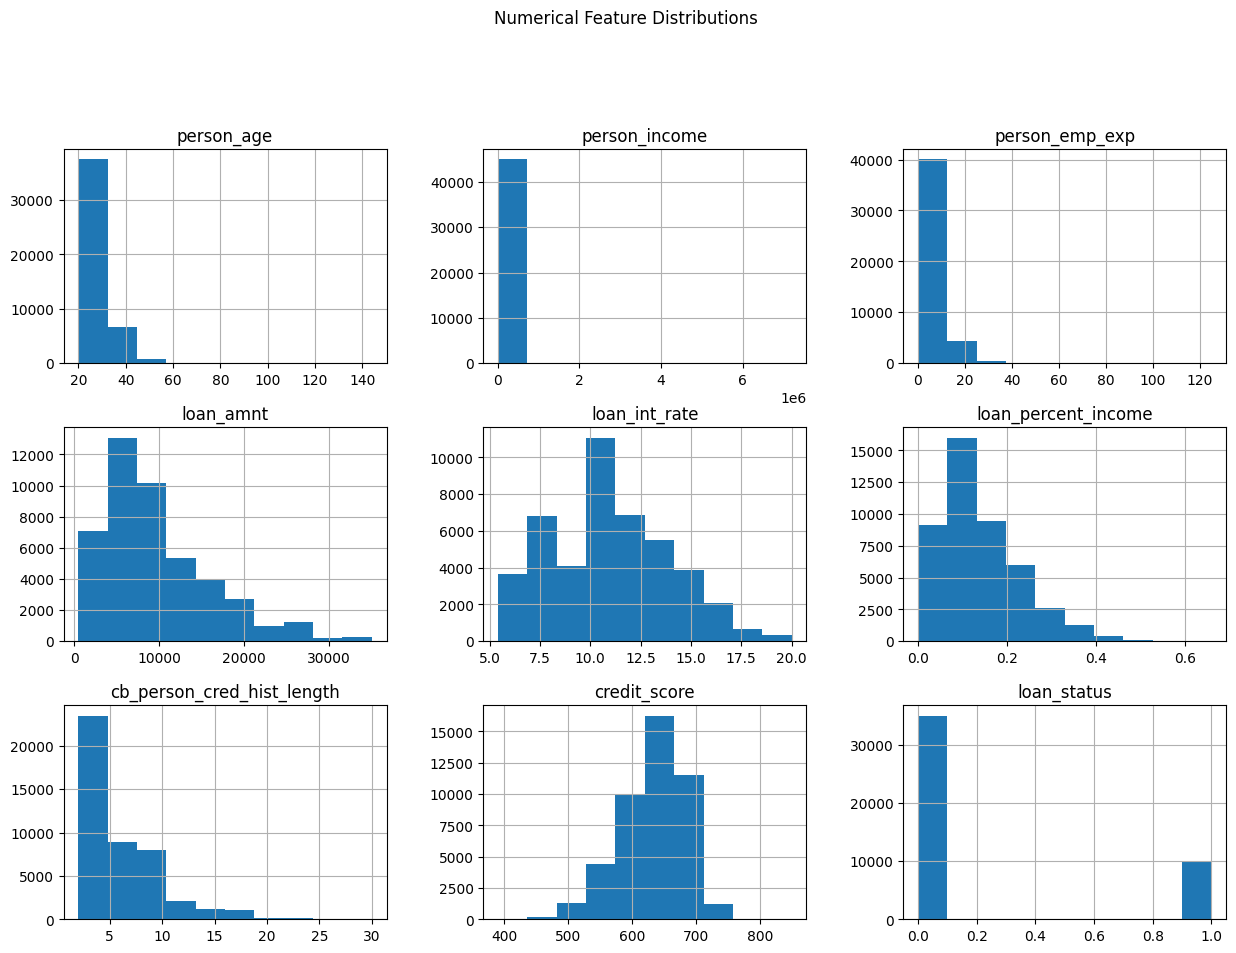

In [6]:
# Numerical Features Distribution
# ------------------------------
df.hist(figsize=(15, 10))
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.show()


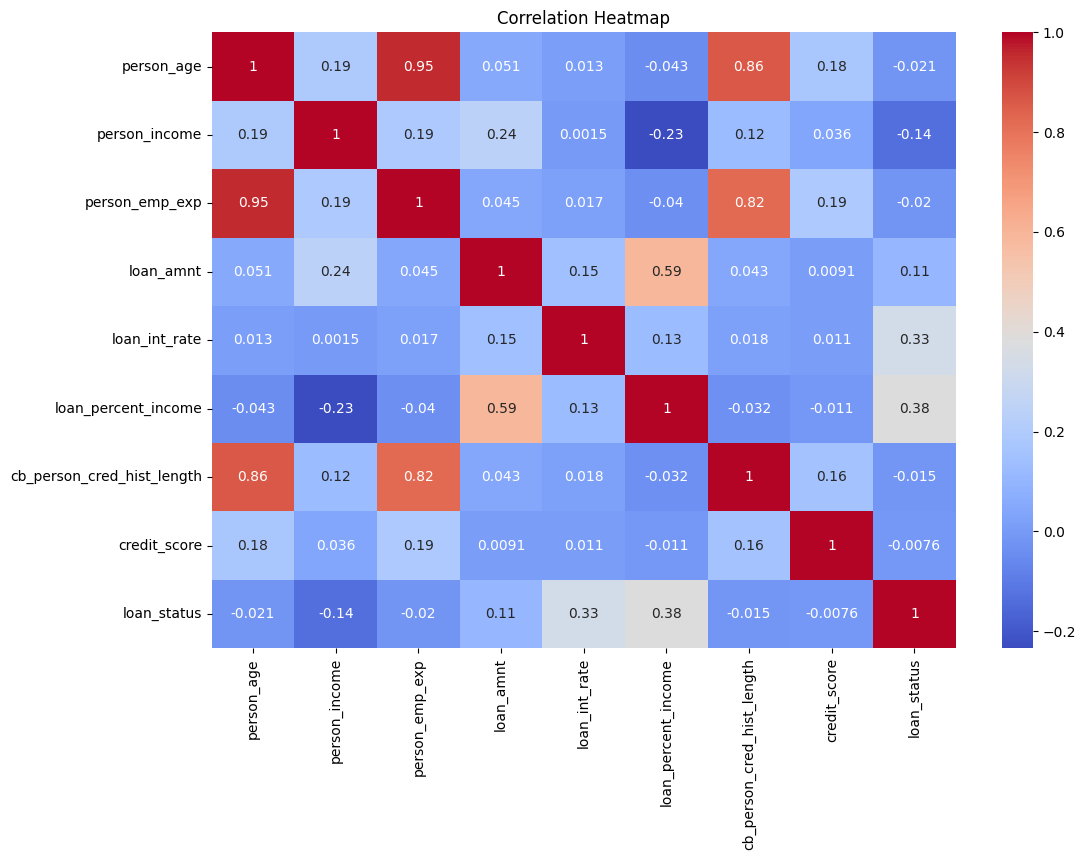

In [7]:
# Correlation Heatmap
# ------------------------------
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [8]:
# Categorical Features Analysis
# ------------------------------
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())



Value Counts for person_gender:
person_gender
male      24841
female    20159
Name: count, dtype: int64

Value Counts for person_education:
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

Value Counts for person_home_ownership:
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

Value Counts for loan_intent:
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

Value Counts for previous_loan_defaults_on_file:
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64


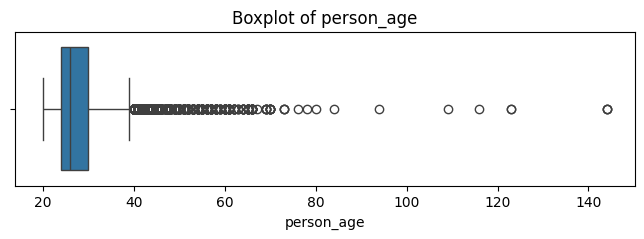

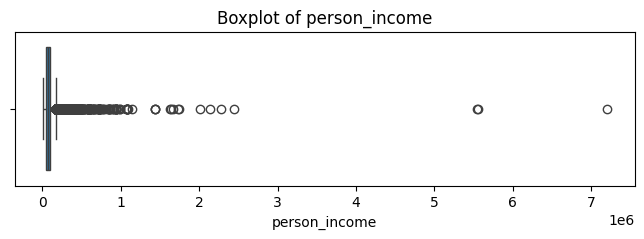

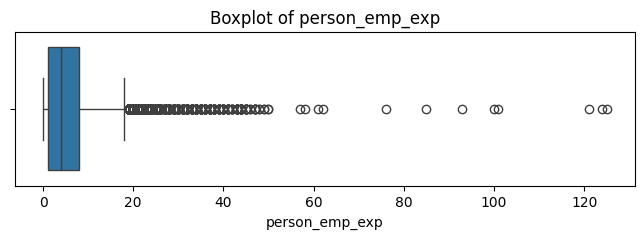

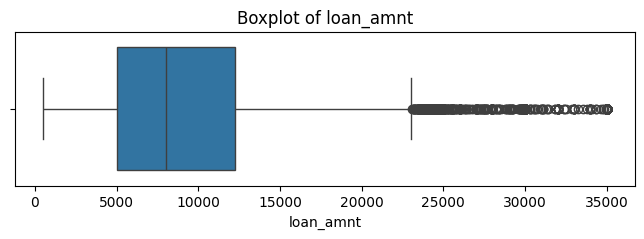

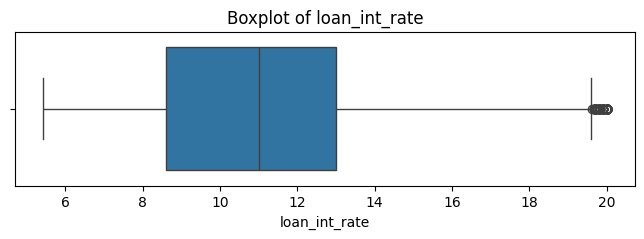

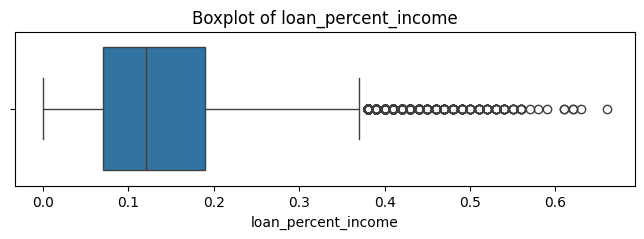

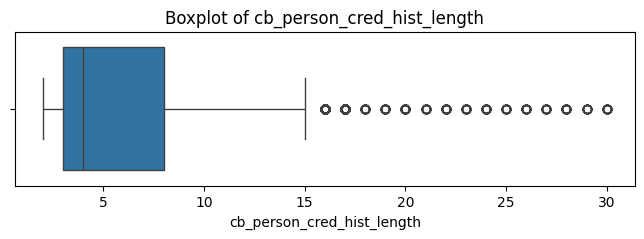

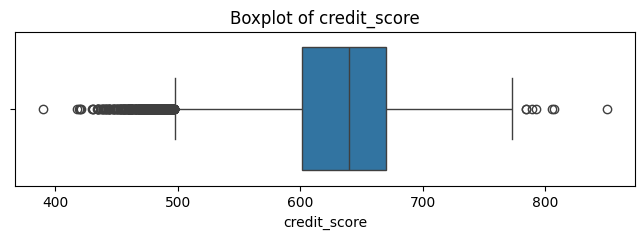

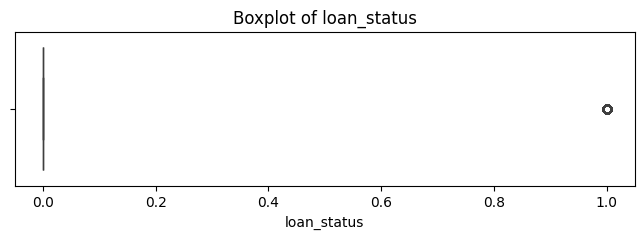

In [9]:
# Boxplots (Outlier Detection)
for col in numeric_df.columns:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [10]:
outliers_age = df[df["person_age"] > 105]

print("Number of records with age > 105:", outliers_age.shape[0])
outliers_age.head()

# Remove unrealistic ages
df_clean = df[df["person_age"] <= 105].copy()
df_clean.reset_index(drop=True, inplace=True)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Number of records with age > 105: 7
Original shape: (45000, 14)
Cleaned shape: (44993, 14)


## 📊 Exploratory Data Analysis (Summary)

The dataset contains 45,000 loan applications with a moderately imbalanced target (~22% defaults).

Key insights:
- Income and loan amount are highly skewed, with clear high-value outliers.
- Age and employment experience contain unrealistic values, which were removed during cleaning.
- Credit score and loan-to-income ratio are strong indicators of default risk.
- Categorical variables are well distributed and suitable for encoding.

Overall, the dataset provides strong predictive signals for building a loan default prediction model.

In [11]:
# 🧹 Remove unrealistic age outliers
# -----------------------------

df_clean = df[df["person_age"] <= 105].copy()

# reset index after removal
df_clean.reset_index(drop=True, inplace=True)

# check result
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Removed rows:", df.shape[0] - df_clean.shape[0])

Original shape: (45000, 14)
Cleaned shape: (44993, 14)
Removed rows: 7


In [12]:
df["person_age"] >= 75].count()


SyntaxError: unmatched ']' (3167917937.py, line 1)

## 🔧 Data Preprocessing & Encoding

In this step, we prepare the dataset for machine learning by converting raw features into a numerical format suitable for model training.

### 📌 Key Steps:
- Separation of features (`X`) and target variable (`loan_status`)
- Cleaning of text-based categorical variables
- Binary encoding of gender and previous loan default history
- One-hot encoding of multi-category features such as education, home ownership, and loan intent

### 🎯 Objective:
To transform the dataset into a fully numerical representation while preserving meaningful information for model learning.

In [ ]:
df_model = df_clean.copy()

X = df_model.drop("loan_status", axis=1)
y = df_model["loan_status"]

X["person_gender"] = X["person_gender"].str.strip().str.lower()
X["previous_loan_defaults_on_file"] = X["previous_loan_defaults_on_file"].str.strip().str.lower()

X["person_gender"] = X["person_gender"].map({"male": 1, "female": 0})
X["previous_loan_defaults_on_file"] = X["previous_loan_defaults_on_file"].map({"yes": 1, "no": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X.head()

In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = [
    "person_education",
    "person_home_ownership",
    "loan_intent"
]

# -----------------------------
# Numeric: ONLY scaling (no imputer)
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# -----------------------------
# Categorical: ONLY encoding (no imputer)
# -----------------------------
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# -----------------------------
# Preprocessor
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 🧠 Final EDA Summary

- The dataset is moderately imbalanced (~22% default rate), which requires appropriate evaluation metrics beyond accuracy.

- Loan-to-income ratio is one of the strongest indicators of default risk.

- Interest rate shows a clear positive relationship with loan default probability.

- Age-related features (age, employment experience, credit history length) are highly correlated, indicating redundancy.

- Extreme outliers in `person_age` (> 90) were identified and removed to improve data quality.

- Categorical variables are well distributed and suitable for modeling without major imbalance concerns.

## 🤖 5. Model Building

In this section, we begin building predictive models to classify whether a loan applicant will default or not.

We start with a **baseline model: Logistic Regression**, which is:
- Simple and interpretable
- Useful for establishing a performance baseline
- Sensitive to linear relationships in the data

### 🎯 Objective:
- Train a baseline classification model
- Evaluate performance using metrics such as:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC

This baseline will help us compare against more advanced models like XGBoost later.

In [ ]:
log_reg = LogisticRegression(max_iter=1000)

log_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", log_reg)
])

# -----------------------------
# Step 2: Train Model
# -----------------------------
log_clf.fit(X_train, y_train)

# -----------------------------
# Step 3: Predictions
# -----------------------------
y_pred = log_clf.predict(X_test)
y_prob = log_clf.predict_proba(X_test)[:, 1]

# -----------------------------
# Step 4: Evaluation
# -----------------------------
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

In [ ]:
# Step 1: Model (WITH imbalance handling)
# -----------------------------
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# -----------------------------
# Step 2: Full Pipeline
# -----------------------------
log_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", log_reg)
])

# -----------------------------
# Step 3: Train
# -----------------------------
log_clf.fit(X_train, y_train)

# -----------------------------
# Step 4: Predictions
# -----------------------------
y_pred = log_clf.predict(X_test)
y_prob = log_clf.predict_proba(X_test)[:, 1]

# -----------------------------
# Step 5: Evaluation
# -----------------------------
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

## 🤖 Logistic Regression (Baseline Model)

We train Logistic Regression as a baseline model and evaluate the impact of handling class imbalance.

### 1️⃣ Without Class Weight
- Balanced performance
- Lower recall for defaulters

### 2️⃣ With Class Weight = "balanced"
- Higher recall for defaulters (0.92)
- Lower precision due to more false positives
- Better for risk-sensitive applications

## 🌲 6. Moving to Random Forest

Next, we train a **Random Forest** model to improve upon the Logistic Regression baseline.

Random Forest helps capture non-linear relationships and generally performs better on complex tabular datasets like this.

We will evaluate its performance using the same metrics for a fair comparison.

In [ ]:
# Step 1: Model
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# -----------------------------
# Step 2: Full Pipeline
# -----------------------------
rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf)
])

# -----------------------------
# Step 3: Train
# -----------------------------
rf_clf.fit(X_train, y_train)

# -----------------------------
# Step 4: Predictions
# -----------------------------
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# -----------------------------
# Step 5: Evaluation
# -----------------------------
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

## 🚀 Moving to XGBoost

After evaluating Logistic Regression and Random Forest, we now move to **XGBoost**, the final and most powerful model in this project.

XGBoost is a gradient boosting algorithm that typically performs very well on structured/tabular data by:
- Correcting previous model errors iteratively
- Handling complex non-linear relationships
- Providing strong control over overfitting

We will use it as the final model to compare performance against previous approaches.

In [ ]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# -----------------------------
# Step 2: Model
# -----------------------------
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

# -----------------------------
# Step 3: Full Pipeline
# -----------------------------
xgb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb)
])

# -----------------------------
# Step 4: Train
# -----------------------------
xgb_clf.fit(X_train, y_train)

# -----------------------------
# Step 5: Predictions
# -----------------------------
y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# -----------------------------
# Step 6: Evaluation
# -----------------------------
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")

print(classification_report(y_test, y_pred_xgb))

### Cross-validation

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_clf,  
    X,        
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Cross-Validation ROC-AUC Scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std ROC-AUC:", cv_scores.std())

Cross-validation was used to evaluate the stability and generalization performance of the XGBoost model.

The consistent ROC-AUC scores across folds indicate that the model is robust and not dependent on a specific train-test split.

## 🔍 Threshold Tuning: Testing Different Decision Cutoffs

In [ ]:
# Step 1: Get probabilities from pipeline model
# -----------------------------
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

# -----------------------------
# Step 2: Test different thresholds
# -----------------------------
thresholds = np.arange(0.1, 0.95, 0.03)

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    print("\n======================")
    print(f"Threshold: {t}")
    print("======================")
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [ ]:
thresholds = np.arange(0.1, 0.95, 0.01)

fp_list = []
fn_list = []
accuracy_list = []

# -----------------------------
# Compute metrics
# -----------------------------
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fp_list.append(fp)
    fn_list.append(fn)

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    accuracy_list.append(accuracy)

# -----------------------------
# Find intersection point (closest FP ≈ FN)
# -----------------------------
diff = np.abs(np.array(fp_list) - np.array(fn_list))
idx = np.argmin(diff)

best_threshold = thresholds[idx]
best_fp = fp_list[idx]
best_fn = fn_list[idx]

# -----------------------------
# Plot FP vs FN
# -----------------------------
plt.figure(figsize=(12, 6))

plt.plot(thresholds, fp_list, label="False Positives (Risk 💥)")
plt.plot(thresholds, fn_list, label="False Negatives (Lost Profit 😐)")

# Mark intersection point
plt.scatter(best_threshold, best_fp, color='red', s=100, zorder=5)
plt.text(
    best_threshold, best_fp,
    f"  Balance Point\n  T={best_threshold:.2f}",
    color='red'
)

plt.xlabel("Threshold")
plt.ylabel("Count")
plt.title("Threshold Trade-off: Risk vs Opportunity")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# Accuracy plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(thresholds, accuracy_list, color="green", label="Accuracy")
plt.scatter(best_threshold, accuracy_list[idx], color='red', s=100)
plt.text(best_threshold, accuracy_list[idx],
         f"  T={best_threshold:.2f}", color='red')

plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Threshold")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# Print result
# -----------------------------
print("Best Balance Threshold (FP ≈ FN):", best_threshold)
print("False Positives:", best_fp)
print("False Negatives:", best_fn)

# 🧠 Cost-Based Threshold Selection (Summary)

## 🔥 Goal
We don’t have real profit data, so we optimize a **business cost function** instead of ML metrics. Although 0.69 is the best balance threshold (FP ≈ FN), it only represents a neutral trade-off point and not necessarily the optimal business decision.

---

## 🏦 Assumptions
- **False Positive (FP)** = risky loan approved → high financial loss  
- **False Negative (FN)** = good borrower rejected → smaller opportunity loss  

---

## ⚖️ Cost Function
\[
Total Cost = (FP \times cost_{fp}) + (FN \times cost_{fn})
\]

---

## 🔄 Process
1. Try different thresholds  
2. Compute FP & FN  
3. Calculate total cost  
4. Select threshold with **minimum cost**

---

## 🧠 Key Idea
We are not optimizing accuracy or AUC — we are optimizing **expected business loss**.

---

## 🏆 Conclusion
Threshold tuning becomes a **business decision problem**, not just a machine learning problem.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# -----------------------------
# Step 1: Get probabilities
# -----------------------------
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

# -----------------------------
# Step 2: Define business costs
# -----------------------------
cost_fp = 10000   
cost_fn = 1000    

# -----------------------------
# Step 3: Test thresholds
# -----------------------------
thresholds = np.arange(0.1, 0.95, 0.01)

results = []

best_threshold = None
best_cost = float("inf")

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    total_cost = (fp * cost_fp) + (fn * cost_fn)

    results.append([t, fp, fn, total_cost])

    if total_cost < best_cost:
        best_cost = total_cost
        best_threshold = t

# -----------------------------
# Step 4: Results table
# -----------------------------
results_df = pd.DataFrame(results, columns=["Threshold", "FP", "FN", "Total_Cost"])

print(results_df.sort_values("Total_Cost").head(10))

print("\n======================")
print("BEST THRESHOLD (MIN COST)")
print("======================")
print("Threshold:", best_threshold)
print("Minimum Cost:", best_cost)

# 🧠 Final Decision: Threshold Selection (Business Justification)

Based on cost-based optimization, the mathematically optimal threshold was found around **0.93**, which strongly minimizes total expected cost under a high-risk assumption.

However, to improve **generalization and robustness to unseen data**, we choose a slightly lower operational threshold:

---

## ⚖️ Final Chosen Threshold: **0.88**

---

# 🔥 Why not use the exact optimal (0.93)?

Even though 0.93 minimizes cost on the test set, it may:

- Overfit to the specific test distribution  
- Be overly conservative in real-world scenarios  
- Lead to excessive rejection of good borrowers (high FN rate)  
- Reduce business growth unnecessarily  

---

# 🧠 Why 0.88 is chosen instead

Choosing **0.88 instead of 0.93** provides:

## ✔ Better generalization
- Slightly relaxes extreme conservatism
- More stable under unseen data shifts

## ✔ Balanced risk control
- Still maintains **low false positives**
- Avoids excessive risky approvals

## ✔ Business practicality
- Prevents over-rejection of good customers
- Keeps system usable in real deployment

---

# ⚖️ Final Interpretation

> While 0.93 is the strict cost-optimal threshold on current data,  
> 0.88 is selected as a **robust production threshold** to mitigate overfitting and ensure stability on unseen real-world data.

---


# 🧠 Model Comparison Summary (Loan Approval)

| Model | ROC-AUC | Key Result | Risk Behavior |
|------|--------|------------|---------------|
| XGBoost (thr=0.88) | ~0.97 | FP = 70, FN = 655 | Most conservative (lowest risk) |
| Random Forest | ~0.97 | FP = 158, FN = 486 | Balanced trade-off |
| Logistic Regression | ~0.95 | FP = 1150, FN = 172 | High risk (too many bad approvals) |

---

# 🏆 Conclusion
XGBoost performs best for credit risk control due to lowest false positives at the chosen threshold, making it most suitable for banking deployment.

In [ ]:
# Step 1: Extract model + preprocessor
# -----------------------------
model = xgb_clf.named_steps["model"]
preprocessor = xgb_clf.named_steps["preprocessor"]

# -----------------------------
# Step 2: Transform data
# -----------------------------
X_test_transformed = preprocessor.transform(X_test)

# -----------------------------
# Step 3: Get feature names
# -----------------------------
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame 
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

# -----------------------------
# Step 4: SHAP explainer
# -----------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed_df)

# -----------------------------
# Step 5: Global plot 
# -----------------------------
shap.summary_plot(shap_values, X_test_transformed_df)

# -----------------------------
# Step 6: Feature importance 
# -----------------------------
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar")

# -----------------------------
# Step 7: Local explanation
# -----------------------------
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test_transformed_df.iloc[0],
    matplotlib=True
)

# 🧠 SHAP Feature Insight

From SHAP analysis, features like **gender** and **education** show very low impact on model predictions, meaning they do not significantly influence loan approval decisions.

---

## 📌 Action Taken
These features can be dropped to simplify the model without losing predictive performance, improving efficiency and reducing noise.

The SHAP plots show that the most important features in the model are:

- `previous_loan_defaults_on_file`
- `loan_int_rate`
- `loan_percent_income`
- `person_income`
- `person_home_ownership_RENT`
- `loan_intent_VENTURE`
- `credit_score`

These features have the highest impact on loan default prediction.

---

## Removing Low-Contribution Features

The SHAP analysis also shows that `person_gender` and education-related features have almost zero contribution to the model output. Therefore, these features will be dropped before training the final model again.

Removed features:
- `person_gender`
- `person_education`

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# -----------------------------
# Step 1: Use CLEANED DATA
# -----------------------------
df_model = df_clean.copy()

# -----------------------------
# Step 2: Drop unwanted columns
# -----------------------------
df_model = df_model.drop(["person_education", "person_gender"], axis=1)

# -----------------------------
# Step 3: Split X and y
# -----------------------------
X = df_model.drop("loan_status", axis=1)
y = df_model["loan_status"]

# -----------------------------
# Step 4: Clean text
# -----------------------------
X["previous_loan_defaults_on_file"] = (
    X["previous_loan_defaults_on_file"]
    .str.strip()
    .str.lower()
)

# -----------------------------
# Step 5: Binary encoding
# -----------------------------
X["previous_loan_defaults_on_file"] = X["previous_loan_defaults_on_file"].map(
    {"yes": 1, "no": 0}
)

# -----------------------------
# Step 6: Categorical columns
# -----------------------------
cat_cols = ["person_home_ownership", "loan_intent"]

# -----------------------------
# Step 7: Preprocessor
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# -----------------------------
# Step 8: Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Step 9: Fit + transform
# -----------------------------
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# -----------------------------
# Step 10: Model
# -----------------------------
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

# -----------------------------
# Step 11: Train
# -----------------------------
xgb.fit(X_train, y_train)

# -----------------------------
# Step 12: Predictions (THRESHOLD = 0.88)
# -----------------------------
y_proba = xgb.predict_proba(X_test)[:, 1]

threshold = 0.88
y_pred = (y_proba >= threshold).astype(int)

# -----------------------------
# Step 13: Evaluation
# -----------------------------
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

XGBoost performs strongly (ROC-AUC ≈ 0.975) with high overall accuracy (~92%), showing very low false positives (72) but a higher number of false negatives (645), meaning it is conservative in approving loans.

## 🧪 Feature Engineering Summary

We experimented with ratio-based features and different encoding strategies (One-Hot vs Label Encoding). However, these transformations did not lead to significant performance improvements, as tree-based models were already able to capture non-linear relationships effectively.

Therefore, we retained a simple preprocessing pipeline and focused on Logistic Regression as the baseline and XGBoost as the final model due to its superior performance.